--- 1. Data Type Identification (Schema) ---
age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

Structured Numeric Columns: ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']
Structured Categorical Columns: ['gender', 'platform_usage', 'social_interaction_level']
--- 2. Parsing Semi-structured Metadata ---
Source System: Teen Health Survey 2024

--- 3. Pivot Analysis Table (Anxiety by Interaction) ---
social_interaction

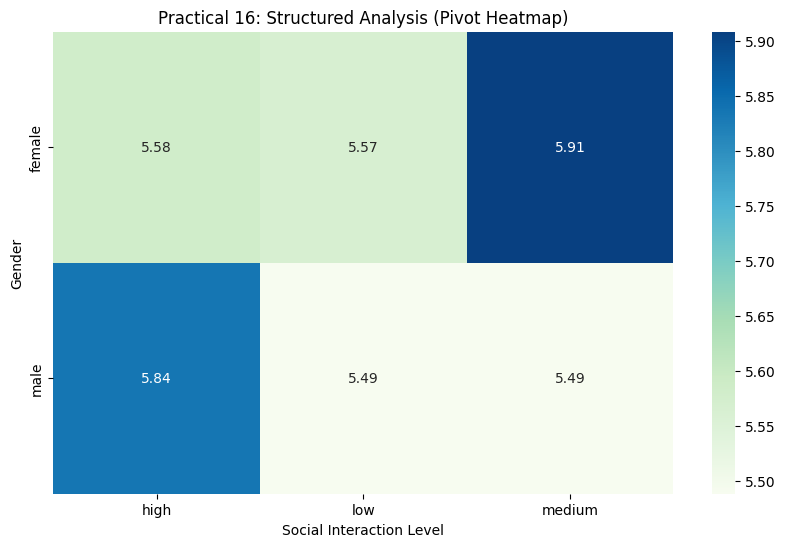

C:\Users\KETAN CHAVADA\AppData\Local\Temp\ipykernel_17832\802356733.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='depression_label', y='daily_social_media_hours', data=df, palette='pastel')


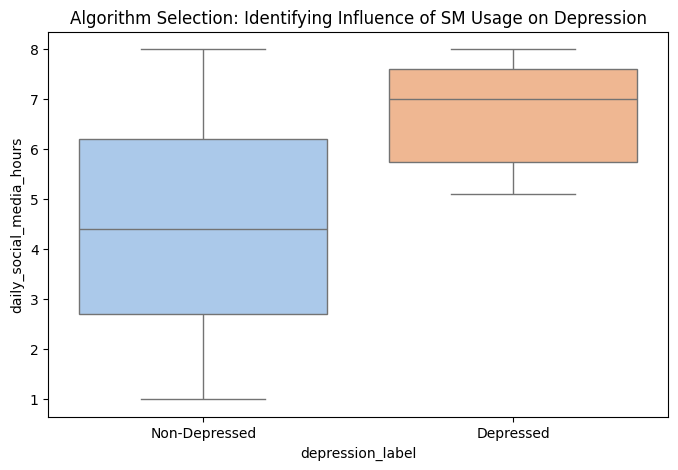

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the structured dataset
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

print("--- 1. Data Type Identification (Schema) ---")
print(df.dtypes)

# Separating Numeric and Categorical columns for different preprocessing pipelines
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nStructured Numeric Columns: {numeric_cols}")
print(f"Structured Categorical Columns: {categorical_cols}")
# Simulating a semi-structured JSON-like engine
metadata = {
    "source": "Teen Health Survey 2024",
    "version": 1.2,
    "parameters": ["stress", "anxiety", "depression"]
}

print(f"--- 2. Parsing Semi-structured Metadata ---")
print(f"Source System: {metadata['source']}")
# Pivot Restructuring (Spreadsheet Logic)
pivot_df = df.pivot_table(index='gender', 
                          columns='social_interaction_level', 
                          values='anxiety_level', 
                          aggfunc='mean')

print("\n--- 3. Pivot Analysis Table (Anxiety by Interaction) ---")
print(pivot_df)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, cmap='GnBu', fmt=".2f")
plt.title('Practical 16: Structured Analysis (Pivot Heatmap)')
plt.xlabel('Social Interaction Level')
plt.ylabel('Gender')
plt.show()
plt.figure(figsize=(8, 5))
sns.boxplot(x='depression_label', y='daily_social_media_hours', data=df, palette='pastel')
plt.title('Algorithm Selection: Identifying Influence of SM Usage on Depression')
plt.xticks([0, 1], ['Non-Depressed', 'Depressed'])
plt.show()

--- Step 1: Data Acquisition ---
Features acquired: ['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']

--- Step 2: Transformation ---
   gender  gender_encoded platform_usage  platform_encoded
0    male               1      Instagram                 1
1  female               0         TikTok                 2
2  female               0      Instagram                 1
3    male               1         TikTok                 2
4  female               0           Both                 0

--- Step 3: Feature Engineering (Normalization) ---
   daily_social_media_hours  sleep_hours  academic_performance
0                  1.657833     0.659177              0.034026
1                 -1.299649     1.075244              0.398282
2                 -1.595397     0.797866              1.612470
3    

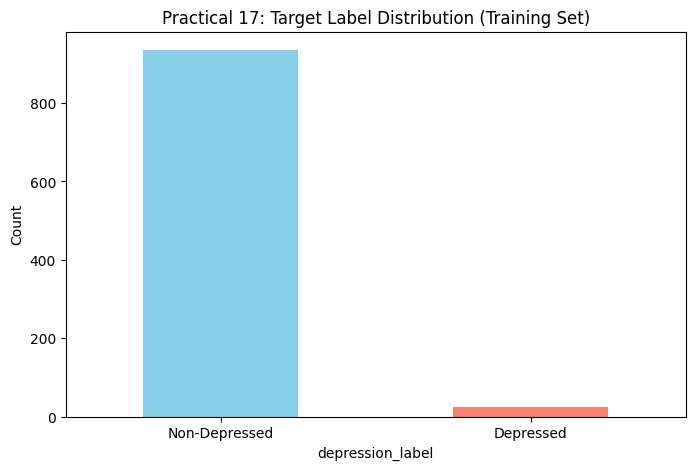

In [2]:
# 17 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the dataset
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

print("--- Step 1: Data Acquisition ---")
print(f"Features acquired: {list(df.columns)}")
# Transform categorical labels into numeric values
le = LabelEncoder()
df['gender_encoded'] = le.fit_transform(df['gender'])
df['platform_encoded'] = le.fit_transform(df['platform_usage'])

print("\n--- Step 2: Transformation ---")
print(df[['gender', 'gender_encoded', 'platform_usage', 'platform_encoded']].head())
# Feature Engineering: Scaling numeric inputs
scaler = StandardScaler()
cols_to_scale = ['daily_social_media_hours', 'sleep_hours', 'academic_performance']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print("\n--- Step 3: Feature Engineering (Normalization) ---")
print(df[cols_to_scale].head())
# Define Features (X) and Target (y)
X = df[['age', 'gender_encoded', 'daily_social_media_hours', 'sleep_hours', 'academic_performance']]
y = df['depression_label']

# Split: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("\n--- Step 4: Data Splitting ---")
print(f"Total Records: {len(df)}")
print(f"Training subset size: {X_train.shape[0]}")
print(f"Testing subset size: {X_test.shape[0]}")
plt.figure(figsize=(8, 5))
y_train.value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Practical 17: Target Label Distribution (Training Set)')
plt.xticks([0, 1], ['Non-Depressed', 'Depressed'], rotation=0)
plt.ylabel('Count')
plt.show()

Step 1: Data Loaded and Missing Values Simulated.
Total Missing Values in 'stress_level': 60
Step 2: Advanced KNN Imputation Complete.
Remaining Missing Values: 0
Step 3: Schema Transformation Complete.
Step 4: Data-Type Normalization Complete.


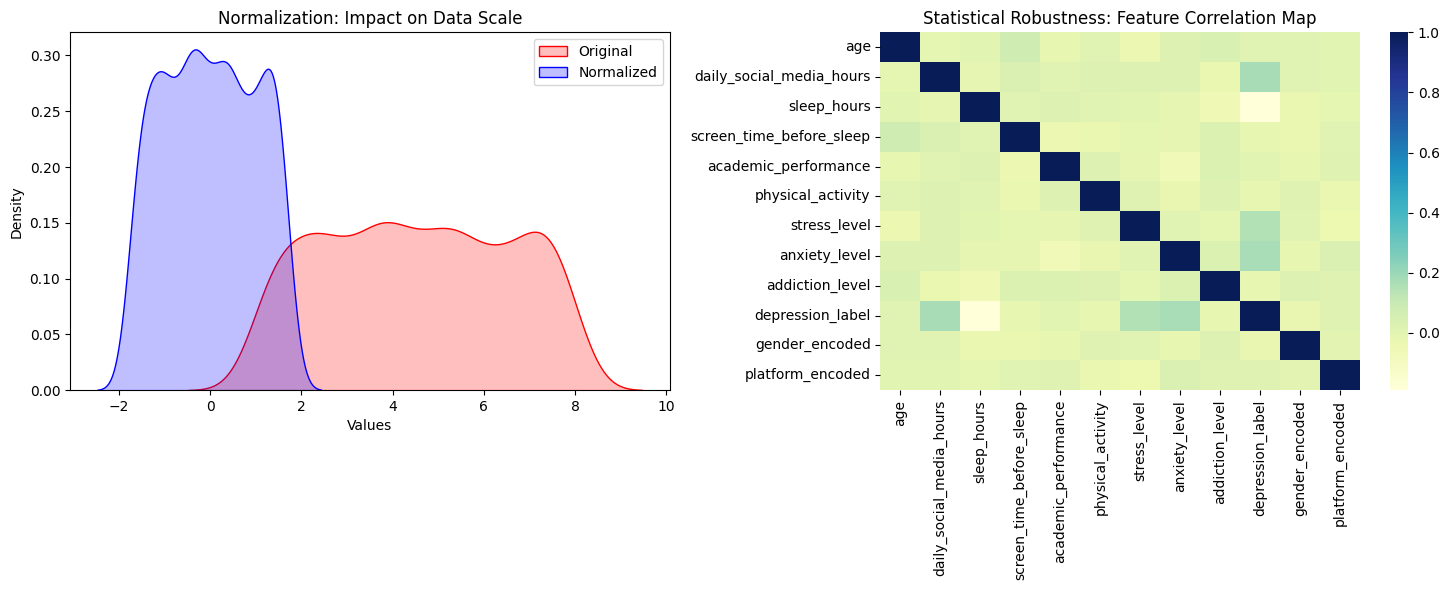

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Load the dataset
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

# 2. Simulate Missing Values (Injecting 5% NaNs in 'stress_level' for demonstration)
np.random.seed(42)
df_missing = df.copy()
ix = df_missing.sample(frac=0.05).index
df_missing.loc[ix, 'stress_level'] = np.nan

print("Step 1: Data Loaded and Missing Values Simulated.")
print(f"Total Missing Values in 'stress_level': {df_missing['stress_level'].isnull().sum()}")
# Select only numeric columns for KNN Imputation
numeric_cols = df_missing.select_dtypes(include=[np.number]).columns
imputer = KNNImputer(n_neighbors=5)

# Perform Imputation
df_imputed = pd.DataFrame(imputer.fit_transform(df_missing[numeric_cols]), columns=numeric_cols)

print("Step 2: Advanced KNN Imputation Complete.")
print(f"Remaining Missing Values: {df_imputed['stress_level'].isnull().sum()}")
# Transforming 'gender' and 'platform_usage' schemas
le = LabelEncoder()
df_missing['gender_encoded'] = le.fit_transform(df_missing['gender'])
df_missing['platform_encoded'] = le.fit_transform(df_missing['platform_usage'])

# Combine imputed numeric data with encoded categorical data
df_final = df_imputed.copy()
df_final['gender_encoded'] = df_missing['gender_encoded'].values
df_final['platform_encoded'] = df_missing['platform_encoded'].values

print("Step 3: Schema Transformation Complete.")
df_final[['gender_encoded', 'platform_encoded']].head()
# Define features to normalize
cols_to_scale = ['daily_social_media_hours', 'sleep_hours', 'academic_performance']
scaler = StandardScaler()

# Apply normalization
df_final[cols_to_scale] = scaler.fit_transform(df_final[cols_to_scale])

print("Step 4: Data-Type Normalization Complete.")
df_final[cols_to_scale].head()
plt.figure(figsize=(15, 6))

# Chart 1: Distribution before vs after Normalization
plt.subplot(1, 2, 1)
sns.kdeplot(df['daily_social_media_hours'], color='red', label='Original', fill=True)
sns.kdeplot(df_final['daily_social_media_hours'], color='blue', label='Normalized', fill=True)
plt.title('Normalization: Impact on Data Scale')
plt.xlabel('Values')
plt.legend()

# Chart 2: Correlation Heatmap for Restructured Data
plt.subplot(1, 2, 2)
sns.heatmap(df_final.corr(), cmap='YlGnBu', annot=False)
plt.title('Statistical Robustness: Feature Correlation Map')

plt.tight_layout()
plt.show()

--- Step 1: Statistical Profiling ---
       stress_level  anxiety_level  addiction_level
count   1200.000000    1200.000000      1200.000000
mean       5.445833       5.636667         5.565000
std        2.903290       2.859453         2.830627
min        1.000000       1.000000         1.000000
25%        3.000000       3.000000         3.000000
50%        5.000000       6.000000         6.000000
75%        8.000000       8.000000         8.000000
max       10.000000      10.000000        10.000000


C:\Users\KETAN CHAVADA\AppData\Local\Temp\ipykernel_17832\511529371.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='gender', y='anxiety_level', data=df, palette='muted', split=True)


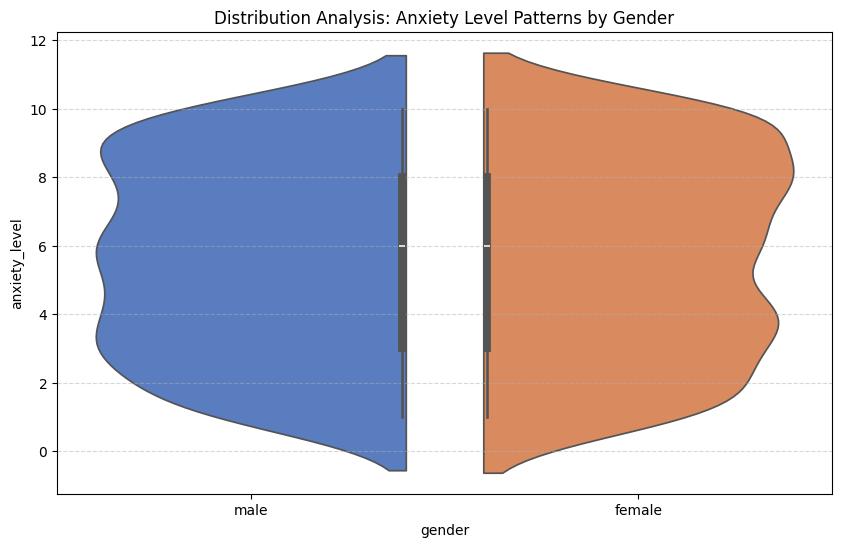

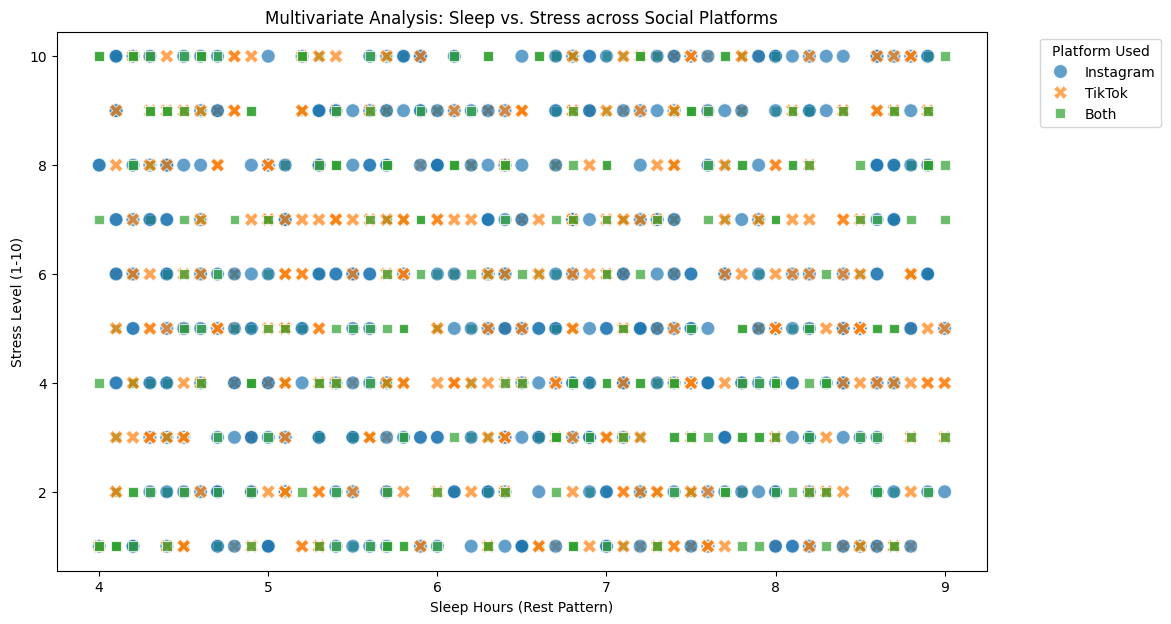

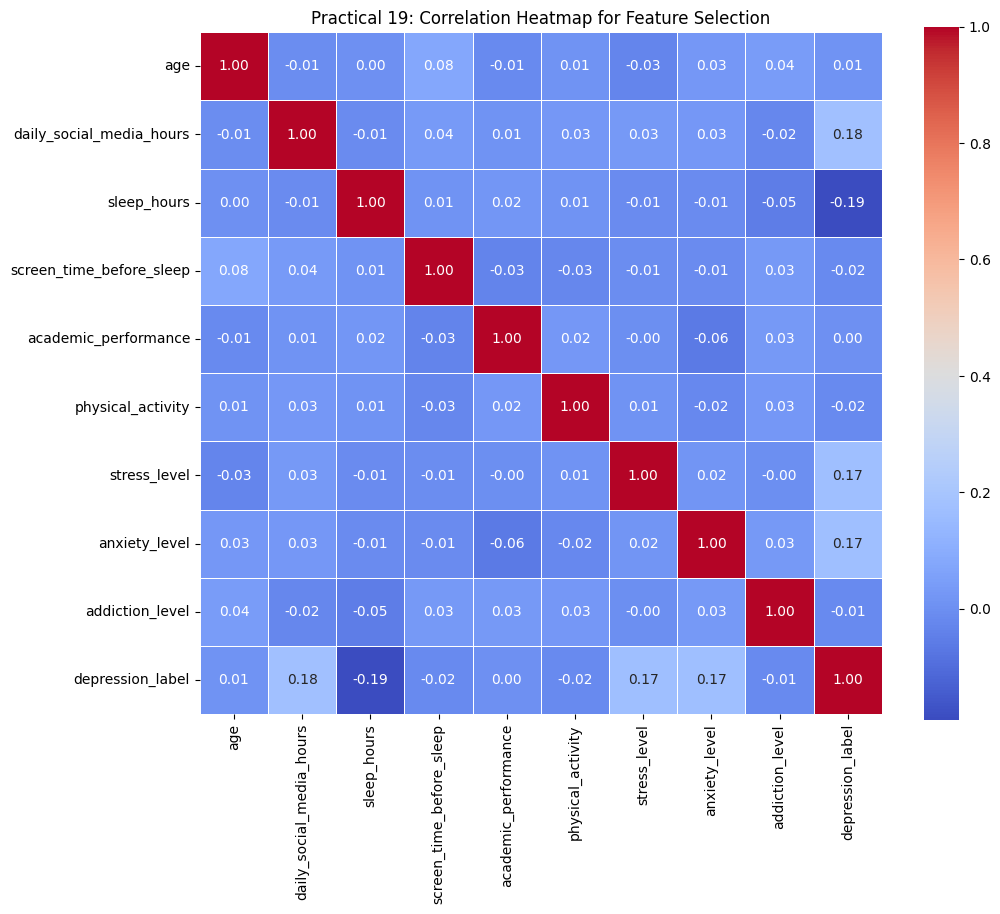

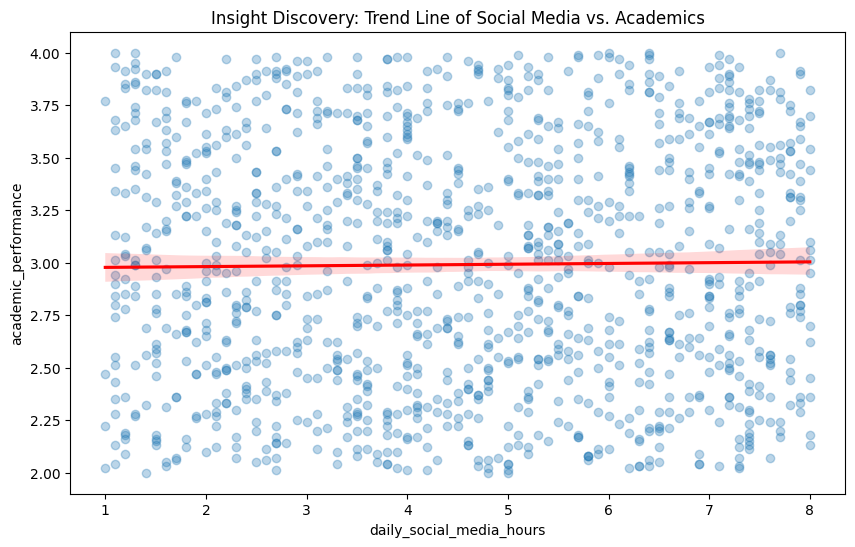

In [10]:
#19 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

print("--- Step 1: Statistical Profiling ---")
# Getting a profile of mental health indicators
profile = df[['stress_level', 'anxiety_level', 'addiction_level']].describe()
print(profile)
plt.figure(figsize=(10, 6))
sns.violinplot(x='gender', y='anxiety_level', data=df, palette='muted', split=True)
plt.title('Distribution Analysis: Anxiety Level Patterns by Gender')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='sleep_hours', y='stress_level', hue='platform_usage', style='platform_usage', s=100, alpha=0.7)
plt.title('Multivariate Analysis: Sleep vs. Stress across Social Platforms')
plt.xlabel('Sleep Hours (Rest Pattern)')
plt.ylabel('Stress Level (1-10)')
plt.legend(title='Platform Used', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
plt.figure(figsize=(11, 9))
# Calculate correlation for numeric columns
corr_matrix = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=.5)
plt.title('Practical 19: Correlation Heatmap for Feature Selection')
plt.show()
plt.figure(figsize=(10, 6))
sns.regplot(x='daily_social_media_hours', y='academic_performance', data=df, 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Insight Discovery: Trend Line of Social Media vs. Academics')
plt.show()

--- Step 1: Dataset Initialized ---
Analyzing 1200 records across mental health metrics.

--- Step 2: Central Tendency Summary ---
        stress_level  anxiety_level  sleep_hours
mean        5.445833       5.636667     6.449417
median      5.000000       6.000000     6.500000

Mode Values:
stress_level     4.0
anxiety_level    6.0
sleep_hours      6.8
Name: 0, dtype: float64

--- Step 3: Dispersion (Spread) Summary ---
       stress_level  anxiety_level  sleep_hours
std         2.90329       2.859453     1.442677
var         8.42909       8.176469     2.081317
min         1.00000       1.000000     4.000000
max        10.00000      10.000000     9.000000
range       9.00000       9.000000     5.000000

--- Step 4: Quantification of Relationships ---
                          daily_social_media_hours  stress_level  \
daily_social_media_hours                  1.000000      0.030698   
stress_level                              0.030698      1.000000   
anxiety_level                      

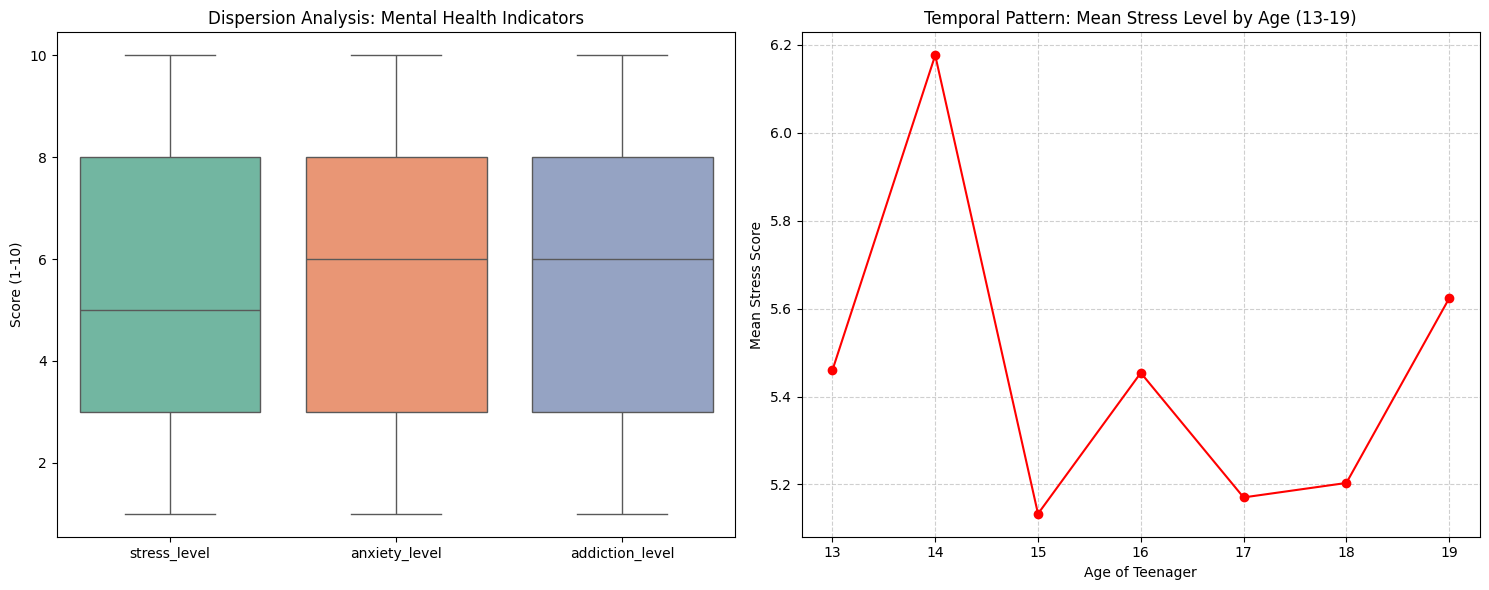

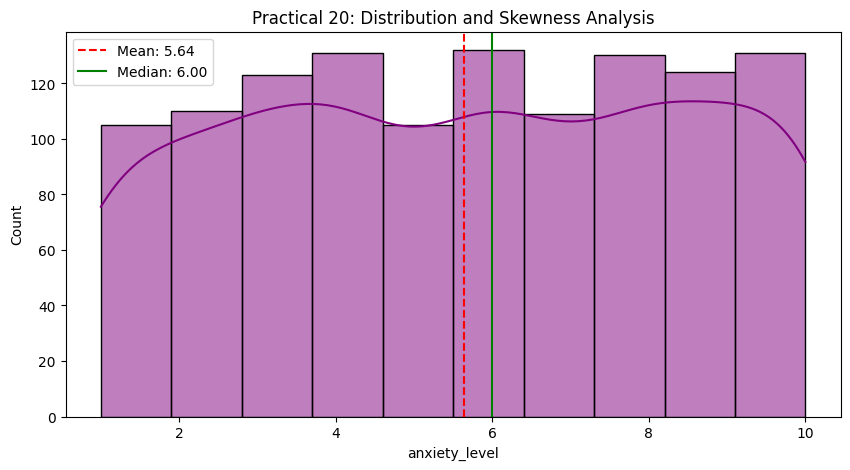

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

print("--- Step 1: Dataset Initialized ---")
print(f"Analyzing {len(df)} records across mental health metrics.")
# Calculating Mean, Median, and Mode for Stress and Anxiety
central_tendency = df[['stress_level', 'anxiety_level', 'sleep_hours']].agg(['mean', 'median'])

# Mode is calculated separately as it can have multiple values
modes = df[['stress_level', 'anxiety_level', 'sleep_hours']].mode().iloc[0]

print("\n--- Step 2: Central Tendency Summary ---")
print(central_tendency)
print("\nMode Values:")
print(modes)
# Calculating Standard Deviation, Variance, and Interquartile Range (IQR)
dispersion = df[['stress_level', 'anxiety_level', 'sleep_hours']].agg(['std', 'var', 'min', 'max'])
dispersion.loc['range'] = dispersion.loc['max'] - dispersion.loc['min']

print("\n--- Step 3: Dispersion (Spread) Summary ---")
print(dispersion)
# Quantifying dependencies
correlation_matrix = df[['daily_social_media_hours', 'stress_level', 'anxiety_level', 'sleep_hours']].corr()

print("\n--- Step 4: Quantification of Relationships ---")
print(correlation_matrix)
plt.figure(figsize=(15, 6))

# Chart 1: Box Plot (Dispersion Visualization)
plt.subplot(1, 2, 1)
sns.boxplot(data=df[['stress_level', 'anxiety_level', 'addiction_level']], palette='Set2')
plt.title('Dispersion Analysis: Mental Health Indicators')
plt.ylabel('Score (1-10)')

# Chart 2: Sequential Trend Analysis (Age-based Patterns)
plt.subplot(1, 2, 2)
# Summarizing mean stress by age to show "temporal" trend
age_trend = df.groupby('age')['stress_level'].mean()
plt.plot(age_trend.index, age_trend.values, marker='o', linestyle='-', color='red')
plt.title('Temporal Pattern: Mean Stress Level by Age (13-19)')
plt.xlabel('Age of Teenager')
plt.ylabel('Mean Stress Score')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 5))
sns.histplot(df['anxiety_level'], kde=True, color='purple', bins=10)
plt.axvline(df['anxiety_level'].mean(), color='red', linestyle='--', label=f'Mean: {df["anxiety_level"].mean():.2f}')
plt.axvline(df['anxiety_level'].median(), color='green', linestyle='-', label=f'Median: {df["anxiety_level"].median():.2f}')
plt.title('Practical 20: Distribution and Skewness Analysis')
plt.legend()
plt.show()